In [ ]:
!pip install -q torch torchvision scikit-learn pandas numpy pillow openpyxl tqdm matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/Upwork/hoofar/batch11.zip'
extraction_path = './batch11'

os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Contents of {zip_file_path} extracted to {extraction_path}")

Contents of /content/drive/MyDrive/Upwork/hoofar/batch11.zip extracted to ./batch11


In [ ]:
import os
import re
import json
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image, UnidentifiedImageError
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DATA_ROOT     = Path("/content/batch11")   # <-- CHANGE THIS
METADATA_FILE = DATA_ROOT / "ebth-rugs_inside11.xlsx"         # <-- CHANGE IF FILENAME DIFFERS
IMAGE_DIR     = DATA_ROOT / "images"                           # contains batch## subfolders

OUTPUT_DIR    = Path("/content/rug_ai_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# ── Training config ───────────────────────────────────────────
TRAIN_SIZE   = 200
TEST_SIZE    = 200
IMG_SIZE     = 224
BATCH_SIZE   = 16
EPOCHS       = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE     = 5
NUM_WORKERS  = 2      # set to 0 if Colab DataLoader crashes

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {DEVICE}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Image dir  : {IMAGE_DIR}")

Device     : cpu
Output dir : /content/rug_ai_output
Image dir  : /content/batch11/images


In [ ]:
TRUE_COLS = [
    'page_link', 'item_url', 'title', 'bid_status', 'end_date', 'end_time',
    'current_bid', 'total_bid_counts', 'description', 'rug_category',
    'materials', 'manufacturing_process', 'approximate_size', 'origin',
    'rug_type', 'condition', 'dimensions', 'item_number', 'image_links',
]

def load_metadata(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path, header=None, skiprows=1)
    df = df.iloc[:, :19]
    df.columns = TRUE_COLS
    df = df.dropna(subset=['item_number']).reset_index(drop=True)
    print(f"Metadata loaded : {len(df)} rows x {len(df.columns)} columns")
    print(f"Sample IDs      : {df['item_number'].head(5).tolist()}")
    return df

df_meta = load_metadata(METADATA_FILE)
df_meta

Metadata loaded : 1000 rows x 19 columns
Sample IDs      : ['17IND185-001', '17COL201-054', '17COL235-008', '17IND163-301-001', '17COL235-008-001']


,page_link,item_url,title,bid_status,end_date,end_time,current_bid,total_bid_counts,description,rug_category,materials,manufacturing_process,approximate_size,origin,rug_type,condition,dimensions,item_number,image_links
0,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/7321111-hand-knotte...,Hand-Knotted Persian Kashan Room Size Rug,Ended,December 6th 2017 @ 7:46pm EST,7:46pm EST,$900,49 Bids,A hand-knotted Persian Kashan room size rug. T...,Area Rug,NaN,Handmade,NaN,NaN,NaN,- minor marks; pulled threads;,"115.0"" W x 0.25"" H x 157.0"" D",17IND185-001,https://imgix-prod.ebth.com/2017/10/26/11/47/0...
1,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/7340077-hand-knotte...,Hand-Knotted Persian Kashan Room Size Rug,Ended,November 9th 2017 @ 6:01pm EST,6:01pm EST,$775,44 Bids,A hand-knotted Persian Kashan room size rug. T...,room size carpet,NaN,Handmade,NaN,NaN,NaN,- one edge appears to have been trimmed,"97.0"" W x 0.5"" H x 132.0"" D",17COL201-054,https://imgix-prod.ebth.com/2017/11/01/19/08/2...
2,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/7764619-hand-knotte...,Hand-Knotted Persian Kashan Room Size Rug,Ended,December 30th 2017 @ 8:18pm EST,8:18pm EST,$892,59 Bids,A hand-knotted Persian Kashan room size rug. T...,Room-Sized Rug,NaN,Handmade,NaN,NaN,NaN,- one edge appears to have been trimmed,"97.0"" W x 0.25"" H x 132.0"" D",17COL235-008,https://imgix-prod.ebth.com/2017/12/24/02/17/0...
3,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/7911103-hand-knotte...,Hand-Knotted Persian Kashan Room Size Rug,Ended,January 28th 2018 @ 5:30pm EST,5:30pm EST,$975,41 Bids,A hand-knotted Persian Kashan room size rug. T...,Area Rug,NaN,Handmade,NaN,NaN,NaN,- marks throughout from use; some pulled thre...,"109.0"" W x 0.25"" H x 155.0"" D",17IND163-301-001,https://imgix-prod.ebth.com/2018/01/11/16/19/0...
4,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/8003386-hand-knotte...,Hand-Knotted Persian Kashan Room Size Rug,Ended,January 31st 2018 @ 8:18pm EST,8:18pm EST,"$1,308",46 Bids,A hand-knotted Persian Kashan room size rug. T...,Room-Sized Rug,NaN,Handmade,NaN,NaN,NaN,- one edge appears to have been trimmed,"97.0"" W x 0.25"" H x 132.0"" D",17COL235-008-001,https://imgix-prod.ebth.com/2018/01/24/12/26/2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/5634192-large-black...,Large Black Fleur-de-Lis Area Rug from the Jew...,Ended,April 14th 2017 @ 7:48pm EST,7:48pm EST,$625,40 Bids,A large area rug by Jewel Collection. It has a...,Area Rug,NaN,Machine Made,NaN,NaN,NaN,Wear from age and use,"102.0"" W x 0.5"" H x 138.0"" D",17LOU089-102,https://imgix-prod.ebth.com/2017/03/28/22/47/5...
996,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/4334574-large-blue-...,Large Blue and White Area Rug,Ended,October 9th 2016 @ 8:13pm EST,8:13pm EST,$707,68 Bids,A large blue and white area rug. This machine ...,Area Rug,NaN,Machine Made,NaN,NaN,NaN,Light soiling. Some loose threads along the ap...,"208.0"" W x 0.5"" H x 148.0"" D",16CIN501-002,https://imgix-prod.ebth.com/2016/09/28/22/00/5...
997,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/3741745-large-cauca...,Large Caucasian Kilim Carpet Runner,Ended,July 17th 2016 @ 4:05pm EST,4:05pm EST,$535,44 Bids,"A large flat woven, Caucasian wool kilim, havi...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"141.0"" W x 0.125"" H x 58.5"" D",16CIN303-187,https://imgix-prod.ebth.com/2016/07/01/15/19/0...
998,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/5968359-large-chine...,Large Chinese Persian Style Silk Area Rug,Ended,June 7th 2017 @ 8:35pm EST,8:35pm EST,$576,57 Bids,A large Chinese Persian style silk area rug. ...,Area Rug,NaN,Handmade,NaN,NaN,NaN,- light areas of wear \n\n

In [ ]:
display(df_meta.describe(include='all'))

,page_link,item_url,title,bid_status,end_date,end_time,current_bid,total_bid_counts,description,rug_category,materials,manufacturing_process,approximate_size,origin,rug_type,condition,dimensions,item_number,image_links
count,1000,1000,1000,1000,1000,1000,1000,1000,924,696,200,707,185,283,0.0,667,998,1000,1000
unique,94,1000,807,1,972,238,336,99,918,10,14,4,49,13,NaN,586,942,1000,1000
top,https://www.ebth.com/decor/rugs-and-carpets?st...,https://www.ebth.com/items/4194505-large-color...,Hand-Knotted Persian Wool Area Rug,Ended,July 31st 2016 @ 8:53pm EST,8:09pm EST,$525,49 Bids,A hand-knotted Persian Kashan room size rug. T...,Area Rug,Wool,Handmade,10′ × 13′,Iran,NaN,- minor wear and discoloration.,"96.0"" W x 0.25"" H x 120.0"" D",16NAS125-115,https://imgix-prod.ebth.com/2016/09/07/01/07/2...
freq,28,1,19,1000,3,24,54,38,3,469,169,621,18,195,NaN,13,6,1,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
STYLE_PATTERNS = [
    ('Kashan',      r'kashan'),
    ('Tabriz',      r'tabriz'),
    ('Heriz',       r'heriz|serapi'),
    ('Oushak',      r'oushak|ushak'),
    ('Sarouk',      r'sarouk|sarough'),
    ('Qum',         r'\bqum\b|\bqom\b'),
    ('Bidjar',      r'bidjar|bijar'),
    ('Turkish',     r'turkish'),
    ('Indian',      r'\bindian\b'),
    ('Kilim',       r'kilim'),
    ('Tibetan',     r'tibetan'),
    ('Isfahan',     r'isfahan'),
    ('Soumak',      r'soumak'),
    ('Hamadan',     r'hamadan'),
    ('Moroccan',    r'moroccan'),
    ('Chinese',     r'chinese'),
    ('Shirvan',     r'shirvan'),
    ('Kazak',       r'kazak'),
    ('Needlepoint', r'needlepoint'),
    ('Sultanabad',  r'sultanabad'),
    ('Flatweave',   r'flat.?weave|flat woven'),
]

def extract_rug_style(title: str) -> str:
    t = str(title).lower()
    for style, pattern in STYLE_PATTERNS:
        if re.search(pattern, t):
            return style
    return 'Other'

df_meta['rug_style'] = df_meta['title'].apply(extract_rug_style)

print("\nRug style distribution (classification target):")
for style, count in df_meta['rug_style'].value_counts().items():
    bar = 'x' * (count // 5)
    print(f"  {style:<14} {count:>4}  {bar}")


Rug style distribution (classification target):
  Other           493  xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
  Tabriz          115  xxxxxxxxxxxxxxxxxxxxxxx
  Heriz            74  xxxxxxxxxxxxxx
  Kashan           68  xxxxxxxxxxxxx
  Sarouk           60  xxxxxxxxxxxx
  Turkish          29  xxxxx
  Oushak           28  xxxxx
  Qum              25  xxxxx
  Indian           22  xxxx
  Bidjar           12  xx
  Tibetan          10  xx
  Isfahan           9  x
  Soumak            9  x
  Hamadan           8  x
  Moroccan          8  x
  Chinese           6  x
  Needlepoint       5  x
  Kilim             5  x
  Kazak             4  
  Shirvan           4  
  Sultanabad        3  
  Flatweave         3  


In [ ]:
def build_image_index(image_dir: Path) -> dict:
    index = {}
    if not image_dir.exists():
        print(f"WARNING: Image directory not found: {image_dir}")
        print("  Script will continue; image loading returns blank tensors.")
        return index

    rug_dirs = sorted([d for d in image_dir.iterdir() if d.is_dir()])
    print(f"Found {len(rug_dirs)} rug folders directly under {image_dir.name}/")

    for rug_dir in rug_dirs:
        index[rug_dir.name] = rug_dir

    print(f"Total rug folders indexed: {len(index)}")
    return index

image_index = build_image_index(IMAGE_DIR)

matched = sum(1 for iid in df_meta['item_number'] if iid in image_index)
print(f"Metadata rows with image folder match: {matched} / {len(df_meta)}")

Found 1000 rug folders directly under images/
Total rug folders indexed: 1000
Metadata rows with image folder match: 1000 / 1000


In [ ]:
#@title Random Subset Selection (400 rugs, seeded)

def select_random_subset(df, n_train=200, n_test=200, seed=42):
    total = n_train + n_test
    if len(df) < total:
        raise ValueError(f"Need {total} rows but only {len(df)} available.")

    sampled = df.sample(n=total, random_state=seed).reset_index(drop=True)

    # Stratified split keeps rare styles in both splits
    try:
        train_df, test_df = train_test_split(
            sampled, train_size=n_train, test_size=n_test,
            stratify=sampled['rug_style'], random_state=seed
        )
    except ValueError:
        train_df = sampled.iloc[:n_train].copy()
        test_df  = sampled.iloc[n_train:].copy()

    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

    overlap = set(train_df['item_number']) & set(test_df['item_number'])
    assert len(overlap) == 0, f"Overlap detected: {overlap}"

    print(f"\nTraining set : {len(train_df)} rugs")
    print(f"Test set     : {len(test_df)} rugs (held out, never seen during training)")
    return train_df, test_df

df_train_raw, df_test_raw = select_random_subset(
    df_meta, n_train=TRAIN_SIZE, n_test=TEST_SIZE, seed=SEED
)

df_train_raw.to_csv(OUTPUT_DIR / "train_ids.csv", index=False)
df_test_raw.to_csv(OUTPUT_DIR / "test_ids.csv",   index=False)
print(f"Saved train_ids.csv and test_ids.csv to {OUTPUT_DIR}")


Training set : 200 rugs
Test set     : 200 rugs (held out, never seen during training)
Saved train_ids.csv and test_ids.csv to /content/rug_ai_output


In [ ]:
#@title Image Audit

def audit_images(df: pd.DataFrame, img_index: dict) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Image audit"):
        iid    = str(row['item_number']).strip()
        folder = img_index.get(iid)
        rec    = {
            'item_number':   iid,
            'folder_exists': folder is not None and folder.exists(),
            'image_count':   0,
            'corrupt_count': 0,
            'avg_width':     None,
            'avg_height':    None,
            'issues':        []
        }

        if not rec['folder_exists']:
            rec['issues'].append('FOLDER_MISSING')
            rec['issues'] = '; '.join(rec['issues'])
            records.append(rec)
            continue

        imgs = [f for f in folder.iterdir() if f.suffix.lower() in VALID_EXT]
        rec['image_count'] = len(imgs)

        if len(imgs) == 0:
            rec['issues'].append('NO_IMAGES')
        elif len(imgs) < 5:
            rec['issues'].append(f'LOW_COUNT({len(imgs)})')

        widths, heights, corrupt = [], [], 0
        for p in imgs:
            try:
                with Image.open(p) as img:
                    img.verify()
                with Image.open(p) as img:
                    widths.append(img.width)
                    heights.append(img.height)
            except Exception:
                corrupt += 1

        rec['corrupt_count'] = corrupt
        if corrupt > 0:
            rec['issues'].append(f'CORRUPT({corrupt})')
        if widths:
            rec['avg_width']  = round(np.mean(widths), 1)
            rec['avg_height'] = round(np.mean(heights), 1)

        rec['issues'] = '; '.join(rec['issues']) if rec['issues'] else 'OK'
        records.append(rec)

    return pd.DataFrame(records)


print("\n" + "="*60)
print("SECTION 1 — IMAGE AUDIT")
print("="*60)

df_audit = audit_images(
    pd.concat([df_train_raw, df_test_raw], ignore_index=True),
    image_index
)
df_audit.to_csv(OUTPUT_DIR / "image_audit_report.csv", index=False)

print(f"\nImage Audit Summary (400 sampled rugs):")
print(f"  Folders found   : {df_audit['folder_exists'].sum()} / {len(df_audit)}")
print(f"  Total images    : {df_audit['image_count'].sum()}")
print(f"  Corrupt images  : {df_audit['corrupt_count'].sum()}")
print(f"  Rugs with issues: {(df_audit['issues'] != 'OK').sum()}")
if df_audit['image_count'].sum() > 0:
    print(f"  Avg images/rug  : {df_audit['image_count'].mean():.1f}")
print(f"\nSaved image_audit_report.csv")


SECTION 1 — IMAGE AUDIT


Image audit: 100%|██████████| 400/400 [00:05<00:00, 69.61it/s]


Image Audit Summary (400 sampled rugs):
  Folders found   : 400 / 400
  Total images    : 4364
  Corrupt images  : 0
  Rugs with issues: 7
  Avg images/rug  : 10.9

Saved image_audit_report.csv


In [ ]:
#@title Metadata Audit

print("\n" + "="*60)
print("SECTION 1 — METADATA AUDIT")
print("="*60)

df_sample = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

AUDIT_COLS = ['rug_category', 'materials', 'origin', 'approximate_size',
              'dimensions', 'current_bid', 'rug_style']

print(f"\nCompleteness — key columns (n={len(df_sample)}):")
for col in AUDIT_COLS:
    if col not in df_sample.columns:
        continue
    filled = (df_sample[col].astype(str).str.strip()
              .replace({'nan': '', 'None': ''}) != '').sum()
    pct  = 100 * filled / len(df_sample)
    icon = "OK " if pct >= 80 else ("LOW" if pct >= 40 else "BAD")
    print(f"  [{icon}] {col:<25} {pct:>5.1f}%  ({filled}/{len(df_sample)})")

def parse_price(val) -> float:
    cleaned = re.sub(r"[^\d.]", "", str(val))
    try:    return float(cleaned)
    except: return np.nan

df_sample['price_num'] = df_sample['current_bid'].apply(parse_price)
prices = df_sample['price_num'].dropna()
if len(prices):
    Q1, Q3 = prices.quantile(0.25), prices.quantile(0.75)
    outs   = prices[(prices < Q1 - 1.5*(Q3-Q1)) | (prices > Q3 + 1.5*(Q3-Q1))]
    print(f"\nPrice (current_bid) stats — n={len(prices)}:")
    print(f"  Min    : ${prices.min():>8,.0f}")
    print(f"  Median : ${prices.median():>8,.0f}")
    print(f"  Mean   : ${prices.mean():>8,.0f}")
    print(f"  Max    : ${prices.max():>8,.0f}")
    print(f"  Outliers (IQR): {len(outs)}")


SECTION 1 — METADATA AUDIT

Completeness — key columns (n=400):
  [LOW] rug_category               69.5%  (278/400)
  [BAD] materials                  20.8%  (83/400)
  [BAD] origin                     31.2%  (125/400)
  [BAD] approximate_size           19.8%  (79/400)
  [OK ] dimensions                 99.8%  (399/400)
  [OK ] current_bid               100.0%  (400/400)
  [OK ] rug_style                 100.0%  (400/400)

Price (current_bid) stats — n=400:
  Min    : $     500
  Median : $     660
  Mean   : $     905
  Max    : $  19,999
  Outliers (IQR): 38


In [ ]:
#@title Preprocessing Pipeline

print("\n" + "="*60)
print("SECTION 1 — PREPROCESSING PIPELINE")
print("="*60)

def parse_dimensions(s) -> tuple:
    # "115.0\" W x 0.25\" H x 157.0\" D" -> (width_in, depth_in)
    nums = re.findall(r'[\d.]+', str(s))
    f    = [float(x) for x in nums]
    if len(f) >= 3: return f[0], f[2]
    if len(f) == 2: return f[0], f[1]
    return np.nan, np.nan

def parse_approx_size(s) -> float:
    # "9' x 13'" -> 117.0 sq-ft
    nums = re.findall(r'[\d.]+', str(s))
    if len(nums) >= 2: return float(nums[0]) * float(nums[1])
    return np.nan

def size_bucket(area):
    if pd.isna(area):  return 'unknown'
    if area < 20:      return 'small'
    if area < 63:      return 'medium'
    if area < 130:     return 'large'
    return 'xlarge'

def parse_bids(v):
    m = re.search(r'(\d+)', str(v))
    return int(m.group(1)) if m else 0

def preprocess_metadata(df, encoders=None, scaler=None, is_train=True):
    df = df.copy()

    # Price
    df['price_num'] = df['current_bid'].apply(parse_price)

    # Dimensions
    dims = df['dimensions'].apply(parse_dimensions)
    df['width_in']     = [d[0] for d in dims]
    df['depth_in']     = [d[1] for d in dims]
    df['area_sqin']    = df['width_in'] * df['depth_in']
    df['aspect_ratio'] = (df['width_in'] / df['depth_in'].replace(0, np.nan)).round(3)

    # Approximate size
    df['area_sqft']   = df['approximate_size'].apply(parse_approx_size)
    df['size_bucket'] = df['area_sqft'].apply(size_bucket)

    # Bid count
    df['bid_count'] = df['total_bid_counts'].apply(parse_bids)

    # Categorical encoding
    CAT_COLS = ['rug_category', 'materials', 'origin', 'size_bucket']
    if encoders is None:
        encoders = {}

    for col in CAT_COLS:
        if col not in df.columns:
            df[col] = 'unknown'
        df[col] = (df[col].fillna('unknown').astype(str)
                   .str.strip().str.lower()
                   .replace({'': 'unknown', 'nan': 'unknown', 'none': 'unknown'}))

        if is_train:
            le = LabelEncoder()
            le.fit(sorted(df[col].unique().tolist()) + ['unknown'])
            encoders[col] = le
        else:
            le    = encoders.get(col)
            known = set(le.classes_) if le else set()
            df[col] = df[col].apply(lambda x: x if x in known else 'unknown')

        df[f'{col}_enc'] = encoders[col].transform(df[col])

    # Feature matrix
    NUM_COLS  = ['width_in', 'depth_in', 'area_sqin', 'aspect_ratio',
                 'area_sqft', 'bid_count']
    ENC_COLS  = [f'{c}_enc' for c in CAT_COLS]
    FEAT_COLS = NUM_COLS + ENC_COLS

    X = df[FEAT_COLS].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    if is_train:
        for col in X.columns: X[col] = X[col].fillna(X[col].median())
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        for col in X.columns: X[col] = X[col].fillna(0)
        X_scaled = scaler.transform(X) if scaler else X.values

    # Classification label (rug style)
    if is_train:
        le_style = LabelEncoder()
        le_style.fit(sorted(df['rug_style'].unique().tolist()))
        encoders['rug_style'] = le_style
    else:
        le_style = encoders.get('rug_style', LabelEncoder())
        known    = set(le_style.classes_)
        df['rug_style'] = df['rug_style'].apply(
            lambda x: x if x in known else le_style.classes_[0])

    y_class = encoders['rug_style'].transform(df['rug_style']).astype(int)
    y_price = np.log1p(df['price_num'].fillna(0).values.astype(float))

    print(f"  Feature matrix : {X_scaled.shape}")
    print(f"  Feature cols   : {FEAT_COLS}")
    return X_scaled, y_class, y_price, encoders, scaler, df, FEAT_COLS


print("\nPreprocessing training metadata...")
(X_train_meta, y_train_class, y_train_price,
 encoders, scaler, df_train_proc, feature_cols) = preprocess_metadata(
     df_train_raw, is_train=True)

print("\nPreprocessing test metadata...")
(X_test_meta, y_test_class, y_test_price,
 _, _, df_test_proc, _) = preprocess_metadata(
     df_test_raw, encoders=encoders, scaler=scaler, is_train=False)

n_classes   = len(encoders['rug_style'].classes_)
class_names = list(encoders['rug_style'].classes_)
print(f"\nClasses ({n_classes}): {class_names}")

with open(OUTPUT_DIR / "encoders.pkl",       "wb") as f: pickle.dump(encoders, f)
with open(OUTPUT_DIR / "scaler.pkl",         "wb") as f: pickle.dump(scaler,   f)
with open(OUTPUT_DIR / "feature_cols.json",  "w")  as f: json.dump(feature_cols, f)
print(f"Saved encoders.pkl, scaler.pkl, feature_cols.json")


SECTION 1 — PREPROCESSING PIPELINE

Preprocessing training metadata...
  Feature matrix : (200, 10)
  Feature cols   : ['width_in', 'depth_in', 'area_sqin', 'aspect_ratio', 'area_sqft', 'bid_count', 'rug_category_enc', 'materials_enc', 'origin_enc', 'size_bucket_enc']

Preprocessing test metadata...
  Feature matrix : (200, 10)
  Feature cols   : ['width_in', 'depth_in', 'area_sqin', 'aspect_ratio', 'area_sqft', 'bid_count', 'rug_category_enc', 'materials_enc', 'origin_enc', 'size_bucket_enc']

Classes (18): [np.str_('Bidjar'), np.str_('Chinese'), np.str_('Hamadan'), np.str_('Heriz'), np.str_('Indian'), np.str_('Isfahan'), np.str_('Kashan'), np.str_('Kazak'), np.str_('Kilim'), np.str_('Moroccan'), np.str_('Other'), np.str_('Oushak'), np.str_('Qum'), np.str_('Sarouk'), np.str_('Soumak'), np.str_('Tabriz'), np.str_('Tibetan'), np.str_('Turkish')]
Saved encoders.pkl, scaler.pkl, feature_cols.json


In [ ]:
#@title Image Transform

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Image transform pipelines ready.")

Image transform pipelines ready.


In [ ]:
#@title Pytorch Dataset

class RugDataset(Dataset):
    def __init__(self, df, meta_features, y_class, y_price,
                 img_index, transform=None, max_images=10):
        self.df            = df.reset_index(drop=True)
        self.meta_features = torch.tensor(meta_features, dtype=torch.float32)
        self.y_class       = torch.tensor(y_class,       dtype=torch.long)
        self.y_price       = torch.tensor(y_price,       dtype=torch.float32)
        self.img_index     = img_index
        self.transform     = transform or val_transforms
        self.max_images    = max_images
        self.placeholder   = torch.zeros(3, IMG_SIZE, IMG_SIZE)

    def __len__(self):
        return len(self.df)

    def _load_images(self, item_number):
        folder = self.img_index.get(str(item_number).strip())
        if folder is None or not folder.exists():
            return self.placeholder
        files = sorted([f for f in folder.iterdir()
                         if f.suffix.lower() in VALID_EXT])[:self.max_images]
        tensors = []
        for p in files:
            try:
                with Image.open(p) as img:
                    tensors.append(self.transform(img.convert('RGB')))
            except Exception:
                continue
        if not tensors:
            return self.placeholder
        return torch.stack(tensors).mean(dim=0)   # average across images

    def __getitem__(self, idx):
        item_num = self.df.iloc[idx]['item_number']
        return (self._load_images(item_num),
                self.meta_features[idx],
                self.y_class[idx],
                self.y_price[idx])


# Internal 80/20 split of training set
# Use stratify only if all classes have >= 2 samples; otherwise fall back to simple split

from collections import Counter

style_counts = Counter(y_train_class)
min_count = min(style_counts.values())

if min_count >= 2:
    train_idx, val_idx = train_test_split(
        np.arange(len(df_train_raw)),
        test_size=0.2,
        stratify=y_train_class,
        random_state=SEED
    )
    print(f"Stratified split: {len(train_idx)} train / {len(val_idx)} val")
else:
    # Some classes have only 1 sample — drop stratification
    print(f"Note: {sum(1 for c in style_counts.values() if c < 2)} class(es) have only 1 sample.")
    print("Falling back to non-stratified split.")
    train_idx, val_idx = train_test_split(
        np.arange(len(df_train_raw)),
        test_size=0.2,
        stratify=None,
        random_state=SEED
    )
    print(f"Simple split: {len(train_idx)} train / {len(val_idx)} val")

print(f"\nInternal split: {len(train_idx)} train / {len(val_idx)} val")

ds_train = RugDataset(df_train_raw.iloc[train_idx].reset_index(drop=True),
                       X_train_meta[train_idx], y_train_class[train_idx],
                       y_train_price[train_idx], image_index, train_transforms)

ds_val   = RugDataset(df_train_raw.iloc[val_idx].reset_index(drop=True),
                       X_train_meta[val_idx], y_train_class[val_idx],
                       y_train_price[val_idx], image_index, val_transforms)

ds_test  = RugDataset(df_test_raw.reset_index(drop=True),
                       X_test_meta, y_test_class, y_test_price,
                       image_index, val_transforms)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS)

print(f"Train loader : {len(ds_train)} rugs, {len(loader_train)} batches")
print(f"Val loader   : {len(ds_val)} rugs")
print(f"Test loader  : {len(ds_test)} rugs")

Note: 3 class(es) have only 1 sample.
Falling back to non-stratified split.
Simple split: 160 train / 40 val

Internal split: 160 train / 40 val
Train loader : 160 rugs, 10 batches
Val loader   : 40 rugs
Test loader  : 200 rugs


In [ ]:
#@title Multimodal Model Architecture

class RugAIModel(nn.Module):
    """
    Multimodal model:
      Image branch   : ResNet-50 (ImageNet pretrained) -> 2048-d
      Metadata branch: MLP -> 32-d
      Fusion         : concat -> 2080-d
      Output heads   : classification (rug style) + regression (price)
    """

    def __init__(self, n_meta, n_classes, unfreeze_epoch=5):
        super().__init__()
        self.unfreeze_epoch = unfreeze_epoch

        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.img_feat_dim = backbone.fc.in_features   # 2048
        backbone.fc       = nn.Identity()
        self.img_branch   = backbone
        self._set_backbone_grad(False)               # frozen initially

        self.meta_branch = nn.Sequential(
            nn.Linear(n_meta, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),    nn.ReLU()
        )

        fused = self.img_feat_dim + 32   # 2080

        self.cls_head = nn.Sequential(
            nn.Linear(fused, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(fused, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        print(f"RugAIModel init:")
        print(f"  Image  : ResNet-50 -> {self.img_feat_dim}-d")
        print(f"  Meta   : {n_meta}-d -> 32-d")
        print(f"  Fused  : {fused}-d")
        print(f"  Classes: {n_classes}")

    def _set_backbone_grad(self, trainable):
        for p in self.img_branch.parameters():
            p.requires_grad = trainable
        if trainable:
            for name, p in self.img_branch.named_parameters():
                if 'layer3' in name or 'layer4' in name:
                    p.requires_grad = True

    def forward(self, img, meta):
        img_feat  = self.img_branch(img)
        meta_feat = self.meta_branch(meta)
        fused     = torch.cat([img_feat, meta_feat], dim=1)
        return self.cls_head(fused), self.reg_head(fused).squeeze(1)


n_meta = X_train_meta.shape[1]
model  = RugAIModel(n_meta=n_meta, n_classes=n_classes).to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 98.6MB/s]


RugAIModel init:
  Image  : ResNet-50 -> 2048-d
  Meta   : 10-d -> 32-d
  Fused  : 2080-d
  Classes: 18


In [ ]:
#@title Loss, Optimizer, Scheduler

cls_loss_fn = nn.CrossEntropyLoss()
reg_loss_fn = nn.MSELoss()
ALPHA, BETA = 0.6, 0.4      # cls weight, reg weight

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Optimizer   : Adam  lr={LR}, wd={WEIGHT_DECAY}")
print(f"Loss weights: {ALPHA} x CrossEntropy + {BETA} x MSE(log-price)")

Optimizer   : Adam  lr=0.0001, wd=1e-05
Loss weights: 0.6 x CrossEntropy + 0.4 x MSE(log-price)


In [ ]:
#@title Training Loop

def run_epoch(model, loader, optimizer=None, is_train=True):
    model.train(is_train)
    total_loss = cls_total = reg_total = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for img, meta, y_cls, y_reg in loader:
            img, meta        = img.to(DEVICE), meta.to(DEVICE)
            y_cls, y_reg     = y_cls.to(DEVICE), y_reg.to(DEVICE)
            cls_out, reg_out = model(img, meta)
            loss_cls = cls_loss_fn(cls_out, y_cls)
            loss_reg = reg_loss_fn(reg_out, y_reg)
            loss     = ALPHA * loss_cls + BETA * loss_reg

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            cls_total  += loss_cls.item()
            reg_total  += loss_reg.item()
            all_preds.extend(cls_out.argmax(1).cpu().numpy())
            all_labels.extend(y_cls.cpu().numpy())

    n   = len(loader)
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return {'loss': total_loss/n, 'cls_loss': cls_total/n,
            'reg_loss': reg_total/n, 'accuracy': acc}


history           = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss     = float('inf')
patience_ctr      = 0
best_model_path   = OUTPUT_DIR / "best_model.pt"
backbone_unfrozen = False

print("\n" + "="*60)
print("SECTION 2 — MODEL TRAINING")
print("="*60)
print(f"Up to {EPOCHS} epochs | early-stop patience={PATIENCE}\n")

for epoch in range(1, EPOCHS + 1):

    # Unfreeze backbone after unfreeze_epoch
    if not backbone_unfrozen and epoch > model.unfreeze_epoch:
        model._set_backbone_grad(True)
        backbone_unfrozen = True
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR / 5, weight_decay=WEIGHT_DECAY
        )
        print(f"\nEpoch {epoch}: backbone unfrozen, lr -> {LR/5:.2e}\n")

    tr = run_epoch(model, loader_train, optimizer, is_train=True)
    vl = run_epoch(model, loader_val,   optimizer=None, is_train=False)
    scheduler.step(vl['loss'])

    history['train_loss'].append(tr['loss'])
    history['val_loss'].append(vl['loss'])
    history['train_acc'].append(tr['accuracy'])
    history['val_acc'].append(vl['accuracy'])

    tag = ''
    if vl['loss'] < best_val_loss:
        best_val_loss = vl['loss']
        patience_ctr  = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'val_loss': best_val_loss, 'n_classes': n_classes,
                    'n_meta': n_meta, 'class_names': class_names,
                    'feature_cols': feature_cols}, best_model_path)
        tag = '  <- best saved'
    else:
        patience_ctr += 1

    print(f"Ep {epoch:>2}/{EPOCHS}  "
          f"train_loss={tr['loss']:.4f} acc={tr['accuracy']:.3f}  "
          f"val_loss={vl['loss']:.4f} acc={vl['accuracy']:.3f}{tag}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}")
        break

print(f"\nTraining done — best val_loss={best_val_loss:.4f}")


SECTION 2 — MODEL TRAINING
Up to 30 epochs | early-stop patience=5

Ep  1/30  train_loss=12.5086 acc=0.406  val_loss=8.4452 acc=0.600  <- best saved
Ep  2/30  train_loss=3.0398 acc=0.500  val_loss=2.2609 acc=0.600  <- best saved
Ep  3/30  train_loss=2.0004 acc=0.500  val_loss=1.5305 acc=0.600  <- best saved
Ep  4/30  train_loss=1.9376 acc=0.500  val_loss=1.6091 acc=0.600
Ep  5/30  train_loss=1.6525 acc=0.500  val_loss=1.8258 acc=0.600

Epoch 6: backbone unfrozen, lr -> 2.00e-05

Ep  6/30  train_loss=1.5972 acc=0.500  val_loss=1.8977 acc=0.600
Ep  7/30  train_loss=1.4376 acc=0.500  val_loss=1.5488 acc=0.600
Ep  8/30  train_loss=1.4717 acc=0.500  val_loss=1.3943 acc=0.600  <- best saved
Ep  9/30  train_loss=1.4109 acc=0.500  val_loss=1.3069 acc=0.600  <- best saved
Ep 10/30  train_loss=1.3361 acc=0.500  val_loss=1.2980 acc=0.600  <- best saved
Ep 11/30  train_loss=1.3912 acc=0.500  val_loss=1.2057 acc=0.600  <- best saved
Ep 12/30  train_loss=1.3492 acc=0.500  val_loss=1.1474 acc=0.600 

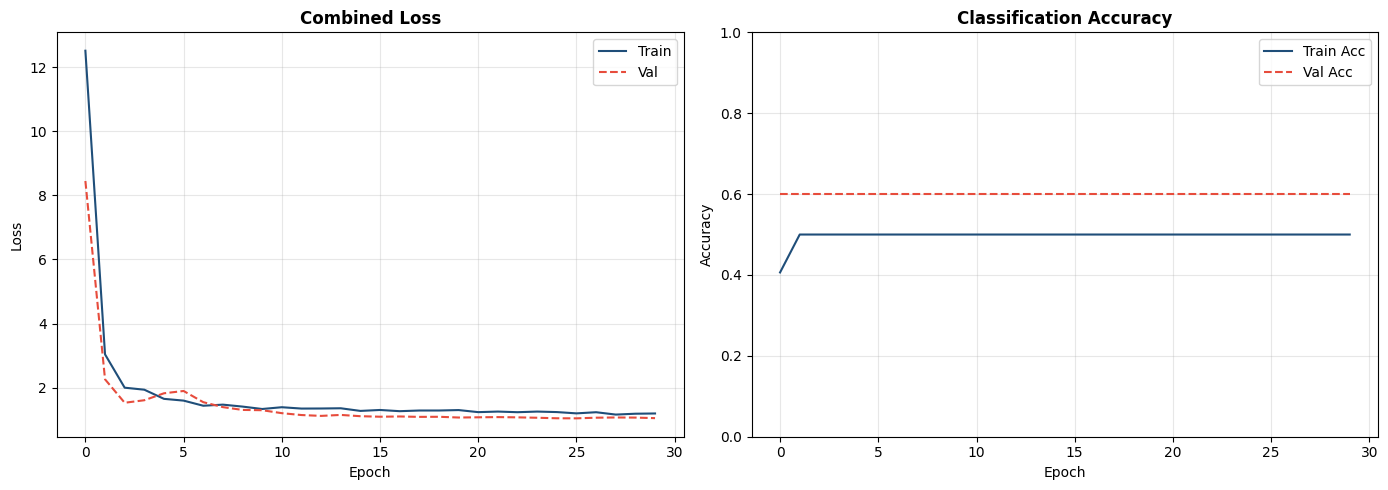

Saved training_history.png


In [ ]:
#@title Training Curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', color='#1F4E79')
ax1.plot(history['val_loss'],   label='Val',   color='#E74C3C', ls='--')
ax1.set_title('Combined Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', color='#1F4E79')
ax2.plot(history['val_acc'],   label='Val Acc',   color='#E74C3C', ls='--')
ax2.set_title('Classification Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_history.png")

In [ ]:
#@title Test Set Evaluation

print("\n" + "="*60)
print("SECTION 3 PREVIEW — TEST SET EVALUATION")
print("="*60)

ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

all_cls_preds, all_cls_labels = [], []
all_reg_preds, all_reg_labels = [], []

with torch.no_grad():
    for img, meta, y_cls, y_reg in tqdm(loader_test, desc="Testing"):
        cls_out, reg_out = model(img.to(DEVICE), meta.to(DEVICE))
        all_cls_preds.extend(cls_out.argmax(1).cpu().numpy())
        all_cls_labels.extend(y_cls.numpy())
        all_reg_preds.extend(reg_out.cpu().numpy())
        all_reg_labels.extend(y_reg.numpy())

cls_labels = np.array(all_cls_labels)
cls_preds  = np.array(all_cls_preds)
accuracy   = np.mean(cls_labels == cls_preds)

print(f"\nClassification — test set (n={len(ds_test)}):")
print(f"  Overall Accuracy: {accuracy:.3f}  ({accuracy*100:.1f}%)")
print(f"\n{classification_report(cls_labels, cls_preds, target_names=class_names, zero_division=0)}")

# Confusion matrix
if n_classes <= 25:
    cm = confusion_matrix(cls_labels, cls_preds)
    sz = max(8, n_classes)
    fig, ax = plt.subplots(figsize=(sz, sz - 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved confusion_matrix.png")

# Price regression metrics
reg_preds  = np.expm1(np.array(all_reg_preds))
reg_labels = np.expm1(np.array(all_reg_labels))
mask       = reg_labels > 0

if mask.sum() > 0:
    rmse = np.sqrt(mean_squared_error(reg_labels[mask], reg_preds[mask]))
    mae  = mean_absolute_error(reg_labels[mask], reg_preds[mask])
    r2   = r2_score(reg_labels[mask], reg_preds[mask])
    mape = np.mean(np.abs((reg_labels[mask]-reg_preds[mask])/reg_labels[mask]))*100

    print(f"\nPrice Estimation — test set:")
    print(f"  RMSE : ${rmse:>8,.2f}")
    print(f"  MAE  : ${mae:>8,.2f}")
    print(f"  R2   : {r2:.4f}")
    print(f"  MAPE : {mape:.1f}%")

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(reg_labels[mask], reg_preds[mask], alpha=0.6,
               color='#2E75B6', edgecolors='white', lw=0.5)
    mx = max(reg_labels[mask].max(), reg_preds[mask].max())
    ax.plot([0, mx], [0, mx], 'r--', lw=1.5, label='Perfect')
    ax.set_title('Predicted vs Actual Price', fontweight='bold')
    ax.set_xlabel('Actual ($)'); ax.set_ylabel('Predicted ($)')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'price_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved price_scatter.png")

# Save per-rug test results
results_df = df_test_raw[['item_number', 'title', 'current_bid']].copy()
results_df['true_style']  = [class_names[i] for i in cls_labels]
results_df['pred_style']  = [class_names[i] for i in cls_preds]
results_df['correct']     = cls_labels == cls_preds
results_df['true_price']  = reg_labels
results_df['pred_price']  = reg_preds
results_df['price_error'] = np.abs(reg_labels - reg_preds)
results_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

# Summary JSON
summary = {
    'timestamp': datetime.now().isoformat(), 'seed': SEED,
    'train_size': TRAIN_SIZE, 'test_size': TEST_SIZE,
    'n_classes': n_classes, 'class_names': class_names,
    'n_meta_features': n_meta, 'feature_cols': feature_cols,
    'best_val_loss': round(best_val_loss, 4),
    'test_accuracy':  round(float(accuracy), 4),
}
if mask.sum() > 0:
    summary.update({'test_rmse': round(float(rmse), 2),
                    'test_mae':  round(float(mae),  2),
                    'test_r2':   round(float(r2),   4),
                    'test_mape': round(float(mape),  2)})

with open(OUTPUT_DIR / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n{'='*60}")
print("PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"  train_ids.csv          -- 200 training rug IDs")
print(f"  test_ids.csv           -- 200 test rug IDs (held out)")
print(f"  image_audit_report.csv -- per-rug image audit")
print(f"  encoders.pkl           -- fitted LabelEncoders")
print(f"  scaler.pkl             -- fitted StandardScaler")
print(f"  feature_cols.json      -- feature column names")
print(f"  best_model.pt          -- trained model checkpoint")
print(f"  training_history.png   -- loss and accuracy curves")
print(f"  confusion_matrix.png   -- test classification heatmap")
print(f"  price_scatter.png      -- predicted vs actual price plot")
print(f"  test_predictions.csv   -- per-rug test results")
print(f"  run_summary.json       -- key metrics summary")


SECTION 3 PREVIEW — TEST SET EVALUATION
Loaded best checkpoint (epoch 26, val_loss=1.0445)


Testing:  38%|███▊      | 5/13 [00:45<00:56,  7.05s/it]